# Exploratory Data Analysis (EDA)

The objective of this analysis is to understand historical healthcare claim denial patterns before building a predictive machine learning model.

This notebook explores:
- Overall denial rate
- Payer performance
- Revenue leakage
- Provider specialties
- Submission delays

In [1]:
from pathlib import Path
import sqlite3

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
DATABASE = PROJECT_ROOT / "data" / "healthcare_claims.db"

conn = sqlite3.connect(DATABASE)

claims = pd.read_sql(
    "SELECT * FROM claims",
    conn
)

conn.close()

claims.head()

,claim_id,patient_id,provider_id,submission_date,payer_name,plan_type,provider_specialty,cpt_code,icd10_code,claim_amount,...,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,claim_status,was_denied,denial_reason,amount_paid,revenue_leakage,denial_probability_true
0,CLM0000001,PAT000298,PRV0051,2025-01-13,Aetna Commercial,Commercial,Dermatology,70553,M17.11,729.58,...,1,1,0,12,Approved,0,Not Denied,678.74,50.84,0.0339
1,CLM0000002,PAT002579,PRV0033,2025-09-21,BlueShield Commercial,Commercial,Dermatology,99214,M17.11,1119.21,...,1,1,0,6,Approved,0,Not Denied,728.30,390.91,0.0373
2,CLM0000003,PAT002182,PRV0079,2025-03-20,Aetna Commercial,Commercial,Gastroenterology,93000,I10,2959.21,...,1,1,0,5,Approved,0,Not Denied,2104.22,854.99,0.0392
3,CLM0000004,PAT001463,PRV0100,2025-09-17,State Medicaid,Medicaid,Orthopedics,99214,I10,5848.79,...,1,1,0,7,Approved,0,Not Denied,4958.09,890.70,0.0794
4,CLM0000005,PAT001443,PRV0040,2025-07-26,Humana Medicare Advantage,Medicare Advantage,Orthopedics,71046,E11.9,5646.59,...,1,1,0,7,Denied,1,Medical Necessity / Other,0.00,5646.59,0.0660


In [2]:
claims.shape

(10000, 24)

In [3]:
claims.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   claim_id                 10000 non-null  str    
 1   patient_id               10000 non-null  str    
 2   provider_id              10000 non-null  str    
 3   submission_date          10000 non-null  str    
 4   payer_name               10000 non-null  str    
 5   plan_type                10000 non-null  str    
 6   provider_specialty       10000 non-null  str    
 7   cpt_code                 10000 non-null  int64  
 8   icd10_code               10000 non-null  str    
 9   claim_amount             10000 non-null  float64
 10  prior_auth_required      10000 non-null  int64  
 11  prior_auth_on_file       10000 non-null  int64  
 12  documentation_complete   10000 non-null  int64  
 13  eligibility_verified     10000 non-null  int64  
 14  provider_credentialed    10000 non

In [4]:
claims.describe()

,cpt_code,claim_amount,prior_auth_required,prior_auth_on_file,documentation_complete,eligibility_verified,provider_credentialed,coding_valid,duplicate_indicator,days_to_submit,was_denied,amount_paid,revenue_leakage,denial_probability_true
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,64134.681800,2166.708884,0.561900,0.901200,0.914900,0.91460,0.971600,0.927800,0.014200,13.143500,0.125400,1505.537773,661.171111,0.120882
std,31545.382244,2244.493203,0.496178,0.298408,0.279044,0.27949,0.166121,0.258832,0.118321,8.882319,0.331188,1777.709762,1171.240376,0.133149
min,11102.000000,90.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.030800
25%,27447.000000,828.640000,0.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,7.000000,0.000000,459.037500,141.697500,0.043100
50%,70553.000000,1501.190000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,11.000000,0.000000,1011.235000,307.465000,0.066000
75%,93000.000000,2687.077500,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,0.000000,18.000000,0.000000,1940.737500,691.995000,0.141900
max,99214.000000,30000.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,80.000000,1.000000,28164.430000,19283.610000,0.969200


In [5]:
claims.isnull().sum()

claim_id                   0
patient_id                 0
provider_id                0
submission_date            0
payer_name                 0
plan_type                  0
provider_specialty         0
cpt_code                   0
icd10_code                 0
claim_amount               0
prior_auth_required        0
prior_auth_on_file         0
documentation_complete     0
eligibility_verified       0
provider_credentialed      0
coding_valid               0
duplicate_indicator        0
days_to_submit             0
claim_status               0
was_denied                 0
denial_reason              0
amount_paid                0
revenue_leakage            0
denial_probability_true    0
dtype: int64

In [6]:
total_claims = len(claims)
denied_claims = claims["was_denied"].sum()
denial_rate = denied_claims / total_claims * 100

print(f"Total Claims: {total_claims:,}")
print(f"Denied Claims: {denied_claims:,}")
print(f"Overall Denial Rate: {denial_rate:.2f}%")

Total Claims: 10,000
Denied Claims: 1,254
Overall Denial Rate: 12.54%


## Business Insight

The overall denial rate provides a baseline measure of the organization's claims performance. A higher denial rate indicates increased administrative workload, delayed reimbursements, and potential revenue leakage. This metric serves as a benchmark for evaluating the effectiveness of future predictive models.

In [7]:
payer_analysis = (
    claims.groupby("payer_name")
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum")
    )
    .reset_index()
)

payer_analysis["denial_rate_pct"] = (
    payer_analysis["denied_claims"]
    / payer_analysis["total_claims"]
    * 100
)

payer_analysis = payer_analysis.sort_values(
    "denial_rate_pct",
    ascending=False
)

payer_analysis

,payer_name,total_claims,denied_claims,denial_rate_pct
1,Ambetter Marketplace,1488,259,17.405914
4,State Medicaid,2068,316,15.280464
3,Humana Medicare Advantage,1993,263,13.196187
0,Aetna Commercial,1952,183,9.375000
2,BlueShield Commercial,2499,233,9.323729


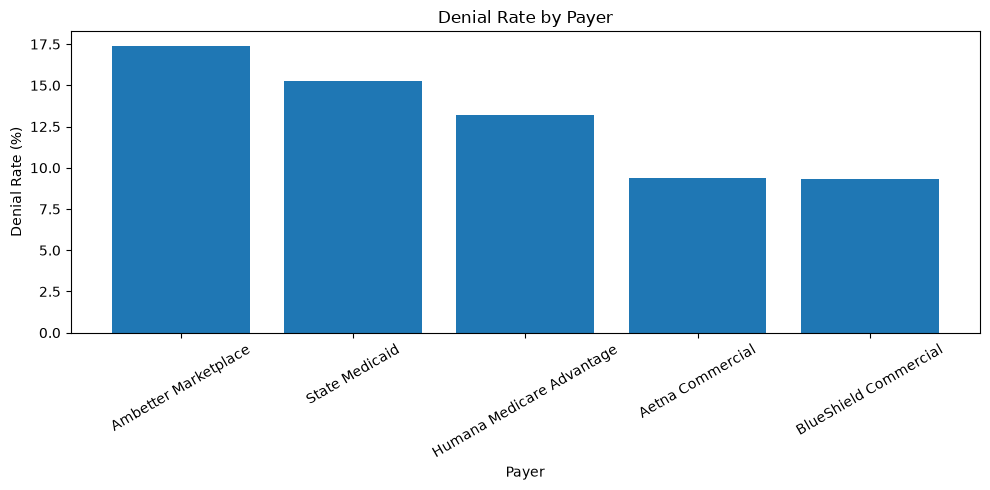

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    payer_analysis["payer_name"],
    payer_analysis["denial_rate_pct"]
)

plt.title("Denial Rate by Payer")
plt.xlabel("Payer")
plt.ylabel("Denial Rate (%)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Business Insight

Denial rates differ across insurance payers, suggesting that payer-specific billing requirements and authorization rules influence claim outcomes. These insights help prioritize process improvements for payers with consistently higher denial rates.

In [9]:
denial_analysis = (
    claims[claims["was_denied"] == 1]
    .groupby("denial_reason")
    .agg(
        denied_claims=("claim_id", "count"),
        revenue_at_risk=("claim_amount", "sum")
    )
    .reset_index()
    .sort_values("revenue_at_risk", ascending=False)
)

denial_analysis

,denial_reason,denied_claims,revenue_at_risk
5,Prior Authorization Missing,386,951184.57
4,Medical Necessity / Other,344,777687.69
3,Eligibility Issue,166,369004.87
1,Documentation Incomplete,124,297488.51
0,Coding Error,103,266542.02
6,Provider Credentialing,68,150783.62
2,Duplicate Claim,61,127995.03
7,Timely Filing,2,1805.58


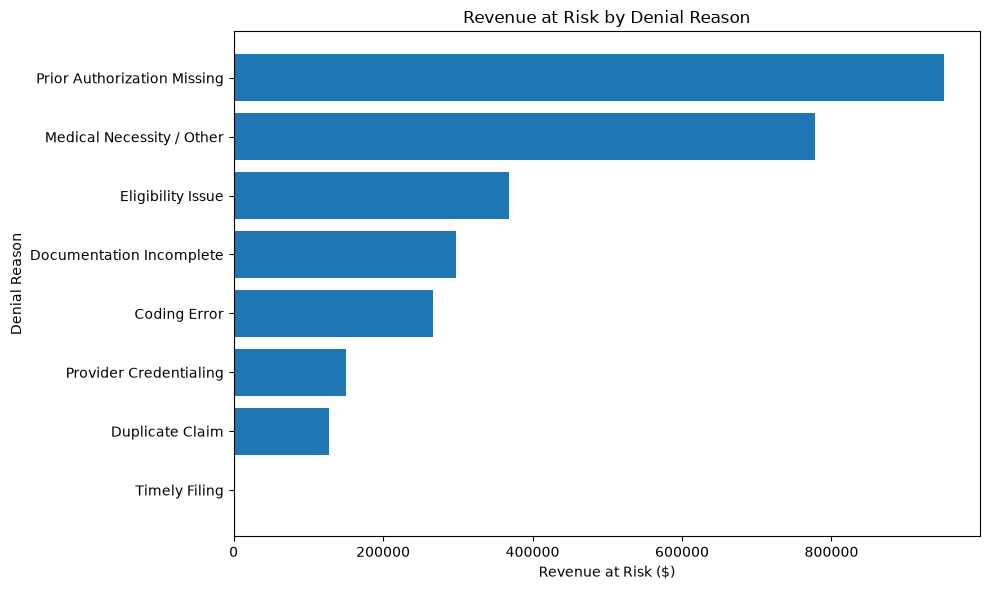

In [10]:
plt.figure(figsize=(10,6))

plt.barh(
    denial_analysis["denial_reason"],
    denial_analysis["revenue_at_risk"]
)

plt.title("Revenue at Risk by Denial Reason")
plt.xlabel("Revenue at Risk ($)")
plt.ylabel("Denial Reason")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Business Insight

Some denial reasons contribute disproportionately to financial losses. Identifying the highest-impact denial categories enables healthcare organizations to prioritize operational improvements that maximize revenue recovery.

In [11]:
specialty_analysis = (
    claims.groupby("provider_specialty")
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum")
    )
    .reset_index()
)

specialty_analysis["denial_rate_pct"] = (
    specialty_analysis["denied_claims"]
    / specialty_analysis["total_claims"]
    * 100
)

specialty_analysis = specialty_analysis.sort_values(
    "denial_rate_pct",
    ascending=False
)

specialty_analysis

,provider_specialty,total_claims,denied_claims,denial_rate_pct
5,Radiology,1412,247,17.492918
3,Orthopedics,1526,250,16.382700
0,Cardiology,1449,177,12.215321
2,Gastroenterology,1412,161,11.402266
1,Dermatology,1387,142,10.237924
4,Primary Care,2814,277,9.843639


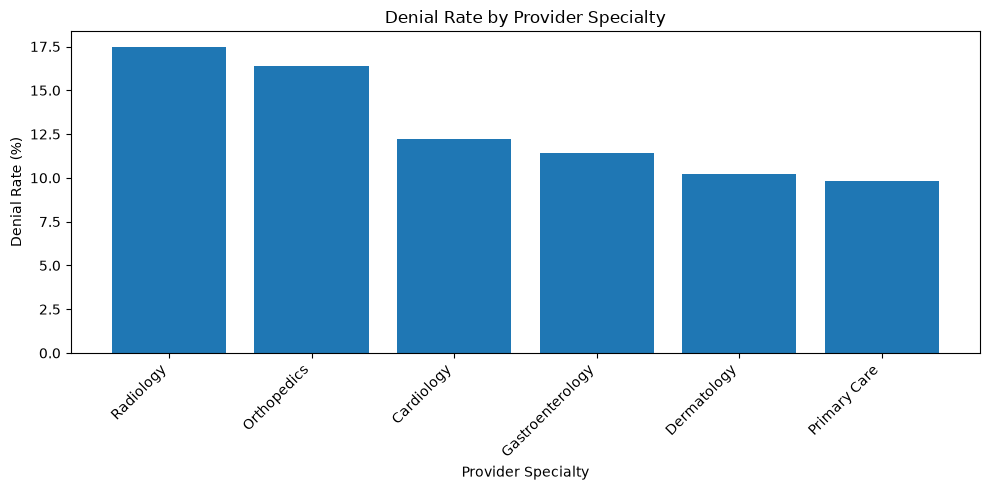

In [12]:
plt.figure(figsize=(10,5))

plt.bar(
    specialty_analysis["provider_specialty"],
    specialty_analysis["denial_rate_pct"]
)

plt.title("Denial Rate by Provider Specialty")
plt.xlabel("Provider Specialty")
plt.ylabel("Denial Rate (%)")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Business Insight

Denial rates vary across provider specialties due to differences in coding complexity, documentation requirements, and payer policies. Identifying specialties with higher denial rates helps organizations target training and process improvements.

In [13]:
claims["submission_delay_group"] = pd.cut(
    claims["days_to_submit"],
    bins=[-1, 7, 14, 30, 60, float("inf")],
    labels=[
        "0–7",
        "8–14",
        "15–30",
        "31–60",
        "60+"
    ]
)

delay_analysis = (
    claims.groupby(
        "submission_delay_group",
        observed=False
    )
    .agg(
        total_claims=("claim_id", "count"),
        denied_claims=("was_denied", "sum")
    )
    .reset_index()
)

delay_analysis["denial_rate_pct"] = (
    delay_analysis["denied_claims"]
    / delay_analysis["total_claims"]
    * 100
)

delay_analysis

,submission_delay_group,total_claims,denied_claims,denial_rate_pct
0,0–7,3030,391,12.904290
1,8–14,3429,420,12.248469
2,15–30,3045,381,12.512315
3,31–60,491,59,12.016293
4,60+,5,3,60.000000


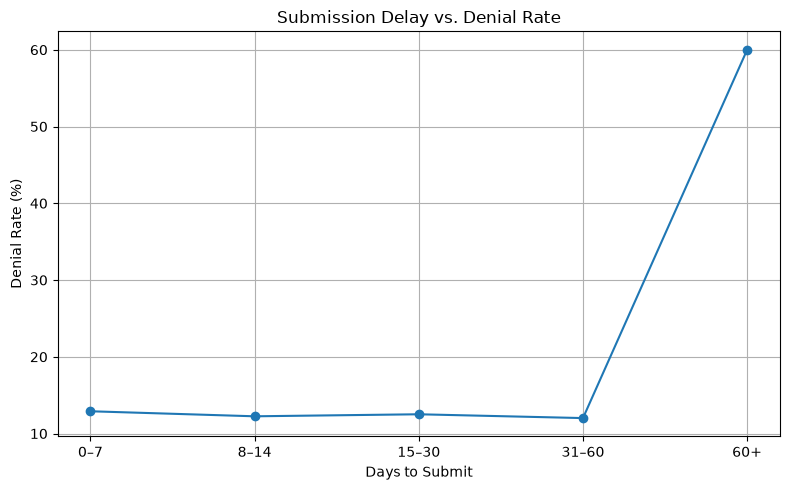

In [14]:
plt.figure(figsize=(8,5))

plt.plot(
    delay_analysis["submission_delay_group"].astype(str),
    delay_analysis["denial_rate_pct"],
    marker="o"
)

plt.title("Submission Delay vs. Denial Rate")
plt.xlabel("Days to Submit")
plt.ylabel("Denial Rate (%)")

plt.grid(True)

plt.tight_layout()
plt.show()

## Business Insight

Longer submission delays are often associated with increased denial rates, suggesting that timely claim submission is an important operational factor. Monitoring submission timelines can help reduce preventable denials.

# Key Findings

The exploratory analysis identified several important business patterns:

- Denial rates vary across insurance payers.
- Certain denial reasons contribute more to revenue leakage than others.
- Provider specialties experience different denial rates.
- Submission delays appear to influence denial outcomes.

These findings provide a strong foundation for predictive modeling. The next step is to build a machine learning model that can identify high-risk claims before submission using only information available at the time a claim is created.